# Basic Neural Radiance Fields (NeRF)

This notebook implements a basic **Neural Radiance Field** (NeRF) from scratch using PyTorch. 

## The Paper: "NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis"
*   **Original Paper**: [Mildenhall et al. ECCV 2020](https://arxiv.org/abs/2003.08934)
*   **Core Concept**: A scene is represented as a continuous 5D function $F(x, y, z, \theta, \phi) \to (r, g, b, \sigma)$, parameterized by a fully connected deep network (MLP).

### 1. The 5D Coordinate Representation
A NeRF takes a **continuous 5D coordinate** as input:
*   **Spatial Location**: $\mathbf{x} = (x, y, z)$
*   **Viewing Direction**: $\mathbf{d} = (\theta, \phi)$

The output is:
*   **Volume Density** $\sigma(\mathbf{x})$: Represents the probability of a ray terminating at location $\mathbf{x}$. Crucially, density is predicted **independent** of the viewing direction (geometry is the same regardless of where you look from).
*   **Color** $\mathbf{c}(\mathbf{x}, \mathbf{d}) = (r, g, b)$: The emitted radiance. Color **depends** on the viewing direction, allowing the model to represent view-dependent effects like specular reflections.

### 2. Network Architecture
The MLP $F_\Theta$ is structured to enforce multiview consistency:
1.  **Input**: 3D position $\mathbf{x}$ (with Positional Encoding).
2.  **Density Network**: Passes through 8 fully-connected layers (ReLU activations, 256 channels). Outputs $\sigma$ and a feature vector.
3.  **View Injection**: The feature vector is concatenated with the viewing direction $\mathbf{d}$ (Positional Encoded).
4.  **Color Network**: Processes the concatenated vector to output RGB color.
   
This structure ensures that the geometry ($\sigma$) is consistent across all views, while color can vary effectively.

### 3. Volume Rendering Equation
To render a pixel, we shoot a ray $\mathbf{r}(t) = \mathbf{o} + t\mathbf{d}$ into the scene and integrate the color along it:
$$ C(\mathbf{r}) = \int_{t_n}^{t_f} T(t) \sigma(\mathbf{r}(t)) \mathbf{c}(\mathbf{r}(t), \mathbf{d}) \, dt $$
where $T(t) = \exp(-\int_{t_n}^t \sigma(\mathbf{r}(s)) ds)$ is the accumulated transmittance (probability that the ray travels from $t_n$ to $t$ without hitting anything).

### 4. Positional Encoding
Deep networks are biased towards learning low-frequency functions (Spectral Bias). To capture high-frequency details (sharp edges, textures), inputs $(x, y, z)$ are mapped to a higher dimensional space using sinusoidal functions:
$$ \gamma(p) = (\sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p)) $$

---

## Comparison with Other Techniques

### NeRF vs. 3D Gaussian Splatting (3DGS)
*   **Representation**: NeRF is **Implicit** (a neural network defines the scene). 3DGS is **Explicit** (millions of discrete Gaussian blobs).
*   **Rendering Speed**: NeRF requires querying a huge MLP hundreds of times *per pixel*, making it slow (seconds/minutes per frame). 3DGS projects Gaussians via rasterization, running in **real-time** (30-100+ FPS).
*   **Training Speed**: NeRF takes hours/days. 3DGS takes minutes/hours.
*   **Quality**: NeRF has less artifacts but can be blurry. 3DGS is sharper but can have "popping" artifacts.

### NeRF vs. Ray Tracing
*   **Paradigm**: Ray Tracing simulates the physical transport of light (bounces, refraction, reflection) to generate an image from geometry. NeRF approximates the *radiance* field directly.
*   **Usage**: Ray Tracing is "Forward Rendering" (Geometry $\to$ Image). NeRF is typically used for "Inverse Rendering" (Images $\to$ Geometry). Basic NeRF does not easily support relighting or moving objects, unlike Ray Tracing.

### NeRF vs. Rasterization (Standard 3D)
*   **Geometry**: Rasterization projects triangles (meshes) onto a 2D screen. NeRF integrates density along a ray.
*   **Differentiability**: Rasterization is hard to differentiate because occlusion (edges) is discontinuous. NeRF's volumetric rendering is smooth and fully differentiable, making it ideal for learning 3D structure from images.

### NeRF vs. Precomputed Radiance Transfer (PRT)
*   **Goal**: PRT solves the rendering equation for static scenes to enable fast real-time relighting with environment maps (using Spherical Harmonics).
*   **Relighting**: PRT separates lighting from transfer functions. Basic NeRF "bakes" the lighting into the radiance field. To achieve PRT-like results, extensions like NeRF-W or Relighting NeRFs disentangle material (BRDF) from illumination.


## Beginner Roadmap (No Graphics/NN Background Required)

This notebook teaches a minimal **Neural Radiance Field (NeRF)** by fitting a red sphere image.

- A **ray** is a line from the camera through one pixel.
- Along each ray, we sample many 3D points.
- A small neural network predicts color and density at each sample point.
- A differentiable renderer blends those predictions into a pixel color.
- Gradient descent updates network weights to match target pixels.

### Diagram 1: End-to-End Workflow
```mermaid
flowchart LR
  A[Camera + Pixels] --> B[Generate Rays]
  B --> C[Sample Points on Each Ray]
  C --> D[Positional Encoding]
  D --> E[NeRF MLP predicts RGB + Density]
  E --> F[Volume Rendering Integration]
  F --> G[Predicted Pixel Colors]
  G --> H[MSE Loss vs Ground Truth]
  H --> I[Backprop + Optimizer Step]
  I --> E
```

### Diagram 2: What Happens on One Ray
```text
camera origin o
   |
   |   ray direction d
   v
o ------------------------------->
   t1      t2      t3      ...     tN
   *-------*-------*--------------*
   x1      x2      x3             xN

At each xi = o + ti * d:
  network(xi) -> (RGB_i, sigma_i)

Renderer converts all samples into one pixel using:
  alpha_i = 1 - exp(-sigma_i * delta_i)
  weight_i = alpha_i * product_{j<i}(1 - alpha_j)
  pixel_color = sum_i(weight_i * RGB_i)
```


### Why This First Code Cell Exists

It prepares the runtime: imports, device selection, and deterministic randomness.
Without this setup, later training behavior can vary between runs and hardware.


In [1]:
# Import PyTorch for tensors, GPU support, and automatic differentiation.
import torch
# Import the neural network module namespace (layers, containers, etc.).
import torch.nn as nn
# Import neural-network helper functions like ReLU and Softplus.
import torch.nn.functional as F
# Import NumPy for random index sampling and numeric utilities.
import numpy as np
# Import Matplotlib for plotting images and training curves.
import matplotlib.pyplot as plt

# Choose CUDA GPU if available, otherwise use CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Print the selected compute device so we know where tensors are running.
print(f"Using device: {device}")

# Fix PyTorch random seed for reproducible model initialization and sampling.
torch.manual_seed(42)
# Fix NumPy random seed for reproducible batch index sampling.
np.random.seed(42)


Using device: cpu


## 1. Scene & Data Generation
We create a synthetic synthetic scene composed of simple geometric objects (Spheres) to train our NeRF on.
Since we don't have an external dataset, we generate "Ground Truth" images by ray-tracing these spheres analytically.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0992501].


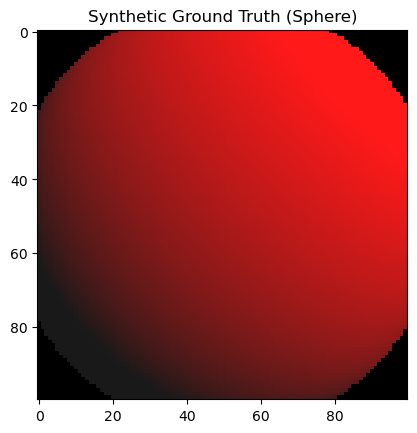

In [2]:
# Convert image pixels into 3D rays in world coordinates.
def get_rays(H, W, focal, c2w):
    # Create pixel x-coordinates from 0 to W-1 and y-coordinates from 0 to H-1.
    i, j = torch.meshgrid(torch.linspace(0, W - 1, W), torch.linspace(0, H - 1, H), indexing='ij')
    # Transpose so i,j align with image row/column convention [H, W].
    i = i.t()
    # Transpose y-grid to match i tensor shape and orientation.
    j = j.t()

    # Convert pixels into camera-frame ray directions using pinhole camera geometry.
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)

    # Rotate camera-frame directions into world-frame directions using c2w rotation.
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3, :3], -1)

    # Copy camera position as the origin for every ray in the image.
    rays_o = c2w[:3, -1].expand(rays_d.shape)

    # Return per-pixel ray origins and directions.
    return rays_o, rays_d

# Render a synthetic sphere analytically to create ground-truth supervision.
def render_sphere_gt(H, W, focal, c2w, radius=0.5, center=torch.tensor([0, 0, -1.0])):
    # Build one ray per pixel for this camera view.
    rays_o, rays_d = get_rays(H, W, focal, c2w)

    # Move rays into sphere-centered coordinates: oc = o - c.
    oc = rays_o - center
    # Quadratic coefficient a for ray-sphere intersection.
    a = torch.sum(rays_d ** 2, dim=-1)
    # Quadratic coefficient b for ray-sphere intersection.
    b = 2.0 * torch.sum(oc * rays_d, dim=-1)
    # Quadratic coefficient c for ray-sphere intersection.
    c = torch.sum(oc ** 2, dim=-1) - radius ** 2

    # Compute discriminant to test whether each ray hits the sphere.
    discriminant = b ** 2 - 4 * a * c
    # Keep only rays with positive discriminant (two real intersections).
    mask = discriminant > 0

    # Initialize output image to black RGB values.
    img = torch.zeros((H, W, 3))

    # Continue only if at least one ray intersects the sphere.
    if mask.any():
        # Choose nearest hit t (front surface) from quadratic formula.
        t = (-b[mask] - torch.sqrt(discriminant[mask])) / (2 * a[mask])
        # Compute 3D hit point coordinates for all intersecting rays.
        hit_points = rays_o[mask] + t.unsqueeze(-1) * rays_d[mask]

        # Compute outward unit normal at each surface hit point.
        normals = (hit_points - center) / radius
        # Define a fixed normalized directional light vector.
        light_dir = torch.tensor([0.577, 0.577, 0.577])

        # Lambertian diffuse shading = max(0, dot(normal, light)).
        diffuse = torch.clamp(torch.sum(normals * light_dir, dim=-1), 0.0, 1.0)
        # Define constant base object color as red.
        col = torch.tensor([1.0, 0.0, 0.0])

        # Write shaded color plus small ambient term into hit pixels.
        img[mask] = col * diffuse.unsqueeze(-1) + 0.1

    # Return synthetic RGB target image.
    return img

# Set test image height and width in pixels.
test_H, test_W = 100, 100
# Set focal length in pixel units for a simple pinhole camera.
test_focal = 100
# Use identity camera-to-world transform (camera at origin, no rotation).
test_c2w = torch.eye(4)
# Render one synthetic ground-truth image of the sphere.
test_gt = render_sphere_gt(test_H, test_W, test_focal, test_c2w)

# Show the generated supervision image.
plt.imshow(test_gt)
# Add title describing what is displayed.
plt.title("Synthetic Ground Truth (Sphere)")
# Render the plot window/output cell figure.
plt.show()


## 2. NeRF Architecture
The model consists of:
1.  **Positional Encoding**: $\gamma(p) = (\sin(2^0 \pi p), \cos(2^0 \pi p), ..., \sin(2^{L-1} \pi p), \cos(2^{L-1} \pi p))$. This maps low-freq positions to high-freq features, enabling the network to learn fine details (spectral bias).
2.  **MLP**: A simple fully connected network.


### Diagram 2A: MLP Inside NeRF (Mermaid Render)\n

In [ ]:
%%html
<div class="mermaid">
flowchart LR
  A[3D point x,y,z] --> B[Positional Encoding]
  B --> C[Encoded vector]
  C --> L1[Linear plus ReLU Layer 1]
  L1 --> L2[Linear plus ReLU Layer 2]
  L2 --> L3[Linear plus ReLU Layer 3]
  L3 --> L4[Linear plus ReLU Layer 4]
  L4 --> S[Skip Connection concat original encoded input]
  C --> S
  S --> L5[Linear plus ReLU Layer 5]
  L5 --> L6[Linear plus ReLU Layer 6]
  L6 --> L7[Linear plus ReLU Layer 7]
  L7 --> L8[Linear plus ReLU Layer 8]
  L8 --> O[Output Linear]
  O --> R[RGB r g b]
  O --> D[Sigma density]
</div>

<script src="https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.min.js"></script>
<script>
  mermaid.initialize({ startOnLoad: true, securityLevel: 'loose' });
  mermaid.run({ querySelector: '.mermaid' });
</script>


In [3]:
# Define positional encoding to map low-frequency coordinates to richer features.
class PositionalEncoding(nn.Module):
    # Construct encoding module with number of frequency bands L_embed.
    def __init__(self, L_embed=6):
        # Initialize parent PyTorch module internals.
        super().__init__()
        # Store number of sinusoidal frequency levels.
        self.L_embed = L_embed

    # Forward pass: encode input 3D points x into higher-dimensional representation.
    def forward(self, x):
        # Start embedding list with original coordinates (identity term).
        emb = [x]
        # For each frequency scale 2^i, append sin and cos projections.
        for i in range(self.L_embed):
            # Append sine features for current frequency band.
            emb.append(torch.sin(2.0 ** i * x))
            # Append cosine features for current frequency band.
            emb.append(torch.cos(2.0 ** i * x))
        # Concatenate all features along last dimension.
        return torch.cat(emb, dim=-1)

# Define a minimal NeRF-style MLP that predicts RGB and density per 3D point.
class NeRF(nn.Module):
    # Build model with depth D, width W, output channels, skip layers, and encoding size.
    def __init__(self, D=8, W=256, output_ch=4, skips=[4], L_embed=6):
        # Initialize parent PyTorch module internals.
        super().__init__()
        # Save skip-connection layer indices.
        self.skips = skips
        # Compute encoded input dimension: xyz + sin/cos bands for each xyz channel.
        input_ch = 3 + 3 * 2 * L_embed

        # Build list of fully connected layers with optional skip input concatenation.
        self.pts_linears = nn.ModuleList(
            [nn.Linear(input_ch, W)] +
            [nn.Linear(W, W) if i not in skips else nn.Linear(W + input_ch, W) for i in range(D - 1)]
        )

        # Final linear layer outputs 4 values: RGB(3) and sigma density(1).
        self.output_linear = nn.Linear(W, output_ch)

    # Forward pass through MLP for encoded point features x.
    def forward(self, x):
        # Initialize hidden activations with encoded input.
        h = x
        # Iterate over each hidden linear layer.
        for i, l in enumerate(self.pts_linears):
            # Apply current linear transformation.
            h = self.pts_linears[i](h)
            # Apply ReLU nonlinearity to hidden activations.
            h = F.relu(h)
            # If this layer is marked as skip, concatenate original input features.
            if i in self.skips:
                # Concatenate along feature dimension to preserve high-frequency input info.
                h = torch.cat([x, h], -1)

        # Map final hidden state to raw RGB+sigma outputs.
        outputs = self.output_linear(h)
        # Return raw network predictions before rendering conversion.
        return outputs


## 3. Differentiable Volumetric Rendering
This is the core physics simulation.
We sample points along the ray, query the model, and integrate.
$$ C = \sum T_i \alpha_i c_i $$
where $\alpha_i = 1 - \exp(-\sigma_i \delta_i)$.


In [4]:
# Convert raw NeRF predictions into rendered color/depth via volume rendering.
def raw2outputs(raw, z_vals, rays_d):
    # Compute distances between consecutive sample depths along each ray.
    dists = z_vals[..., 1:] - z_vals[..., :-1]
    # Create a very large final distance so last sample can absorb remaining transmittance.
    last_dist = torch.tensor([1e10], device=raw.device).expand(dists[..., :1].shape)
    # Append final distance to maintain same sample count as raw predictions.
    dists = torch.cat([dists, last_dist], -1)

    # Scale by ray direction norm to convert depth deltas into metric distances.
    dists = dists * torch.norm(rays_d[..., None, :], dim=-1)

    # Convert first 3 raw channels into [0,1] RGB with sigmoid.
    rgb = torch.sigmoid(raw[..., :3])
    # Keep optional density noise term (set to zero in this simple notebook).
    noise = 0.0
    # Convert raw density channel into strictly positive sigma with Softplus.
    sigma_a = F.softplus(raw[..., 3] + noise)

    # Compute per-sample alpha = probability of terminating at sample i.
    alpha = 1.0 - torch.exp(-sigma_a * dists)

    # Prepend transmittance seed value 1 and accumulate visibility along each ray.
    trans = torch.cumprod(
        torch.cat([torch.ones((alpha.shape[0], 1), device=alpha.device), 1.0 - alpha + 1e-10], -1),
        -1,
    )[:, :-1]
    # Compute final contribution weights = alpha_i * transmittance_i.
    weights = alpha * trans

    # Render RGB as weighted sum of all sample colors on each ray.
    rgb_map = torch.sum(weights[..., None] * rgb, -2)
    # Render expected depth as weighted sum of sampled depths.
    depth_map = torch.sum(weights * z_vals, -1)

    # Return rendered color, depth, and per-sample weights.
    return rgb_map, depth_map, weights

# Render a batch of rays by sampling points, querying NeRF, and compositing outputs.
def render_rays(rays_o, rays_d, model, embedder, near=2.0, far=6.0, N_samples=64):
    # Read compute device from incoming ray tensors.
    device = rays_o.device

    # Uniformly sample N depth values between near and far planes for each ray.
    z_vals = torch.linspace(near, far, N_samples, device=device).expand(rays_o.shape[0], N_samples)

    # Compute midpoints of depth bins for stratified random perturbation.
    mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
    # Build upper bounds for each bin.
    upper = torch.cat([mids, z_vals[..., -1:]], -1)
    # Build lower bounds for each bin.
    lower = torch.cat([z_vals[..., :1], mids], -1)
    # Draw random offsets in [0,1] for stochastic sampling per bin.
    t_rand = torch.rand(z_vals.shape, device=device)
    # Jitter samples inside each bin to reduce aliasing and improve training.
    z_vals = lower + (upper - lower) * t_rand

    # Compute 3D sample points from ray equation x(t) = o + t*d.
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # Flatten points so MLP can process all samples as one batch.
    flat_pts = pts.reshape(-1, 3)
    # Apply positional encoding before passing into NeRF MLP.
    embedded_pts = embedder(flat_pts)

    # Predict raw RGB+sigma for all sampled points.
    raw = model(embedded_pts)
    # Reshape predictions back to [N_rays, N_samples, 4].
    raw = raw.reshape(rays_o.shape[0], N_samples, 4)

    # Perform differentiable volume rendering to obtain final ray outputs.
    rgb_map, depth_map, weights = raw2outputs(raw, z_vals, rays_d)

    # Return color and depth per ray.
    return rgb_map, depth_map


## 4. Training Loop
1.  **Data**: Generate random rays from our view.
2.  **Forward**: Render rays using NeRF.
3.  **Loss**: MSE between Render and Ground Truth ($L = ||C - C_{gt}||^2$).
4.  **Backend**: Adam Optimizer.


### Diagram 3: Training Loop Logic
```mermaid
flowchart TD
  A[Initialize model + optimizer] --> B[Sample random ray batch]
  B --> C[Render predicted RGB for those rays]
  C --> D[Compute MSE loss to target RGB]
  D --> E[loss.backward]
  E --> F[optimizer.step]
  F --> G{More iterations?}
  G -- Yes --> B
  G -- No --> H[Render full image]
```


Starting Training...


Iter 0: Loss 0.1401


Iter 100: Loss 0.0096


Iter 200: Loss 0.0067


Iter 300: Loss 0.0010


...

Iter 700: Loss 0.0001


Iter 800: Loss 0.0001


Iter 900: Loss 0.0001


Iter 1000: Loss 0.0002
Rendering Final Result...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0992501].


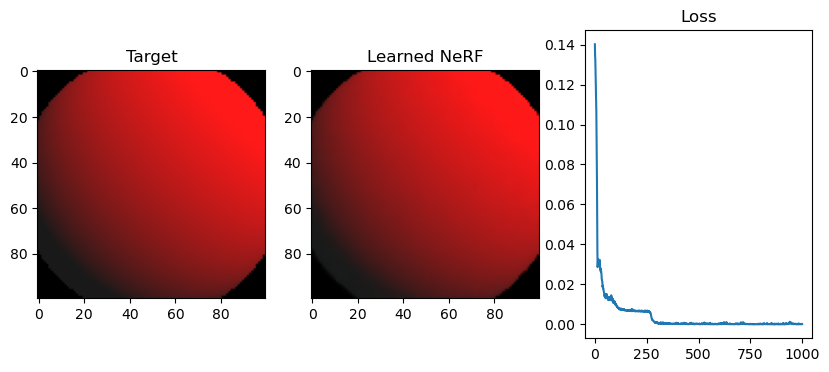

In [5]:
# Set number of positional encoding frequency bands.
L_embed = 6
# Create positional encoder module and move it to selected device.
embedder = PositionalEncoding(L_embed=L_embed).to(device)
# Create NeRF model and move it to selected device.
model = NeRF(L_embed=L_embed).to(device)
# Create Adam optimizer to update model parameters.
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Define total number of training iterations.
N_iters = 1001
# Define number of random rays used per optimization step.
batch_size = 1024
# Define how often to print progress.
print_every = 100

# Create list to store scalar loss values over time.
history_loss = []

# Generate full ray set for the test image once (used for batching and final render).
test_rays_o, test_rays_d = get_rays(test_H, test_W, test_focal, test_c2w)
# Flatten ray origins from image grid [H,W,3] to list [H*W,3].
test_rays_o = test_rays_o.reshape(-1, 3).to(device)
# Flatten ray directions from image grid [H,W,3] to list [H*W,3].
test_rays_d = test_rays_d.reshape(-1, 3).to(device)
# Flatten target image RGB from [H,W,3] to [H*W,3].
test_target = test_gt.reshape(-1, 3).to(device)

# Print training start message.
print("Starting Training...")

# Run gradient-based optimization loop.
for i in range(N_iters):
    # Set model to training mode.
    model.train()

    # Randomly choose ray indices for this minibatch (single-view overfit demo).
    idxs = np.random.choice(test_rays_o.shape[0], batch_size, replace=False)
    # Gather minibatch ray origins using sampled indices.
    batch_rays_o = test_rays_o[idxs]
    # Gather minibatch ray directions using sampled indices.
    batch_rays_d = test_rays_d[idxs]
    # Gather minibatch target RGB values using sampled indices.
    batch_target = test_target[idxs]

    # Render predicted RGB and depth for selected rays.
    rgb, depth = render_rays(batch_rays_o, batch_rays_d, model, embedder, near=0.5, far=1.5)

    # Compute mean squared error between predicted and target RGB.
    loss = torch.mean((rgb - batch_target) ** 2)

    # Clear old gradients before backpropagation.
    optimizer.zero_grad()
    # Backpropagate loss to compute gradients of all trainable parameters.
    loss.backward()
    # Apply one optimizer update step.
    optimizer.step()

    # Save scalar loss value for later plotting.
    history_loss.append(loss.item())

    # Periodically print training progress.
    if i % print_every == 0:
        # Show current iteration number and loss.
        print(f"Iter {i}: Loss {loss.item():.4f}")

        # Disable gradients for quick evaluation snippets.
        with torch.no_grad():
            # Compute middle row index (placeholder for optional quick diagnostics).
            row_idx = test_H // 2

# Print final render start message.
print("Rendering Final Result...")
# Set model to evaluation mode.
model.eval()
# Prepare list to collect rendered RGB chunks.
all_rgb = []
# Choose chunk size to avoid high memory usage when rendering all rays.
chunk = 1024
# Disable gradients during final inference rendering.
with torch.no_grad():
    # Iterate over all rays in chunks.
    for j in range(0, test_rays_o.shape[0], chunk):
        # Slice chunk of ray origins.
        batch_rays_o = test_rays_o[j:j + chunk]
        # Slice chunk of ray directions.
        batch_rays_d = test_rays_d[j:j + chunk]
        # Render chunk RGB predictions.
        rgb, _ = render_rays(batch_rays_o, batch_rays_d, model, embedder, near=0.5, far=1.5)
        # Move chunk to CPU and append for concatenation.
        all_rgb.append(rgb.cpu())

# Concatenate all chunks and reshape back to image grid.
final_img = torch.cat(all_rgb, 0).reshape(test_H, test_W, 3)

# Create figure for side-by-side qualitative and quantitative results.
plt.figure(figsize=(10, 4))
# Plot target ground-truth image.
plt.subplot(1, 3, 1)
# Draw target image content.
plt.imshow(test_gt.cpu())
# Add title for target panel.
plt.title("Target")
# Plot learned NeRF rendering.
plt.subplot(1, 3, 2)
# Draw predicted final image.
plt.imshow(final_img)
# Add title for prediction panel.
plt.title("Learned NeRF")
# Plot loss curve over iterations.
plt.subplot(1, 3, 3)
# Draw training loss history values.
plt.plot(history_loss)
# Add title for loss panel.
plt.title("Loss")
# Render final figure.
plt.show()
